<a href="https://colab.research.google.com/github/Elian-Art/Okun_Law_France/blob/main/Okun_law_France.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Okun's law, France(2000-2026)

Empirical test of Okun's Law on french macroeconomics data. Does GDP growth predict changes in the unemployement rate ?

Data sources: FRED ( Federal reserve bank of St. Louis)

Tools: Python, pandas, numpy, matplotlib, scipy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
print("setup OK")


setup OK


In [ ]:
import requests

def get_fred_data(series_id, api_key="YOUR_API_KEY"):
  url="https://api.stlouisfed.org/fred/series/observations"
  params={
      "series_id": series_id,
      "api_key": api_key,
      "file_type": "json",
      "observations_start":"2000-01-01"

  }
  response= requests.get(url, params=params)
  data= response.json()
  df= pd.DataFrame(data["observations"])
  df["date"] = pd.to_datetime(df["date"])
  df["value"] = pd.to_numeric(df["value"], errors="coerce")
  return df[["date", "value"]]

pib =get_fred_data("CLVMNACSCAB1GQFR")
chomage = get_fred_data("LRHUTTTTFRQ156S")

print(pib.head())
print(chomage.head())

        date  value
0 1975-01-01    NaN
1 1975-04-01    NaN
2 1975-07-01    NaN
3 1975-10-01    NaN
4 1976-01-01    NaN
        date     value
0 1983-01-01  6.833333
1 1983-04-01  7.200000
2 1983-07-01  7.600000
3 1983-10-01  7.900000
4 1984-01-01  8.133333


In [ ]:
pib = pib[pib["date"]>= "2000-01-01"].dropna()
chomage = chomage[chomage["date"]>= "2000-01-01"].dropna()

print(pib.head())
print(chomage.head())

          date     value
100 2000-01-01  431460.2
101 2000-04-01  436435.1
102 2000-07-01  439854.3
103 2000-10-01  442443.6
104 2001-01-01  444669.9
         date     value
68 2000-01-01  9.633333
69 2000-04-01  9.300000
70 2000-07-01  9.000000
71 2000-10-01  8.766666
72 2001-01-01  8.566667


In [ ]:
pib["growth"]= pib["value"].pct_change(4)*100
chomage["change"]= chomage["value"].diff(4)

pib = pib.dropna()
chomage = chomage.dropna()

print(pib.head())
print(chomage.head())


          date     value    growth
104 2001-01-01  444669.9  3.061627
105 2001-04-01  444846.6  1.927320
106 2001-07-01  447426.0  1.721411
107 2001-10-01  445438.3  0.676855
108 2002-01-01  448027.1  0.754987
         date     value    change
72 2001-01-01  8.566667 -1.066666
73 2001-04-01  8.500000 -0.800000
74 2001-07-01  8.400000 -0.600000
75 2001-10-01  8.366667 -0.399999
76 2002-01-01  8.200000 -0.366667


In [ ]:
fusion = pd.merge(pib[["date", "growth"]], chomage[["date", "change"]], on="date")

slope, intercept, r_value, p_value, std_err = stats.linregress(fusion["growth"], fusion["change"])

print(f"coefficient d'Okun (β): {slope:.3f}")
print(f"Constante (α): {intercept:.3f}")
print(f"coefficient de corrélation (R²): {r_value**2:.3f}")
print(f"P-value: {p_value:.4f}")

coefficient d'Okun (β): -0.017
Constante (α): -0.036
coefficient de corrélation (R²): 0.007
P-value: 0.4165


In [ ]:
print(fusion.head(10))

        date    growth    change
0 2001-01-01  3.061627 -1.066666
1 2001-04-01  1.927320 -0.800000
2 2001-07-01  1.721411 -0.600000
3 2001-10-01  0.676855 -0.399999
4 2002-01-01  0.754987 -0.366667
5 2002-04-01  1.188522 -0.300000
6 2002-07-01  1.012078 -0.100000
7 2002-10-01  1.548542  0.033333
8 2003-01-01  1.251665  0.100000
9 2003-04-01  0.337500  0.300000


In [ ]:
fusion_clean = fusion[(fusion["date"]<"2020-01-01") | (fusion["date"]> "2021-06-01")]

slope, intercept, r_value, p_value, std_err = stats.linregress(fusion_clean["growth"], fusion_clean["change"])

print(f"coefficient d'Okun (β): {slope:.3f}")
print(f"Constante (α): {intercept:.3f}")
print(f"coefficient de corrélation (R²): {r_value**2:.3f}")
print(f"P-value: {p_value:.4f}")

coefficient d'Okun (β): -0.271
Constante (α): 0.348
coefficient de corrélation (R²): 0.401
P-value: 0.0000


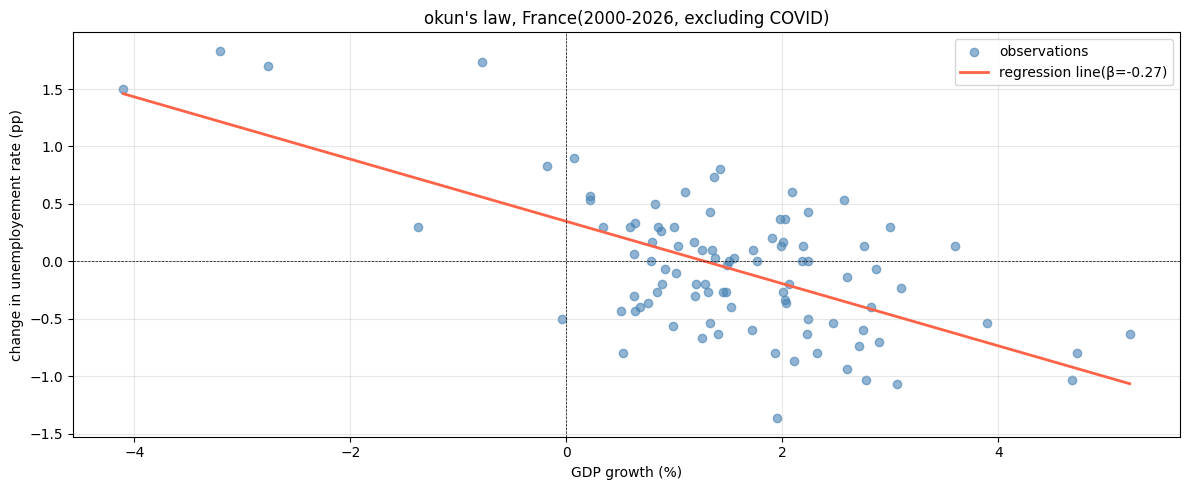

In [ ]:
plt.figure(figsize=(12,5))
plt.scatter(fusion_clean["growth"], fusion_clean["change"],
            color="steelblue", alpha=0.6, label="observations"
            )

x_line = np.linspace(fusion_clean["growth"].min(), fusion_clean["growth"].max(), 100)
y_line = slope*x_line + intercept

plt.plot(x_line, y_line, color="tomato", linewidth=2, label=f"regression line(β={slope:.2f})")
plt.axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.axvline(0, color="black", linewidth=0.5, linestyle="--")
plt.title("okun's law, France(2000-2026, excluding COVID)")
plt.xlabel("GDP growth (%)")
plt.ylabel("change in unemployement rate (pp)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Results

### 1. Okun's law confirmed

over the period 2000-2026, excluding the COVID-19 years, the Okun coefficient is -0.271: a 1% increase in GDP growth is associated with a 0.27 percentage point decrease in unemployement. With an R² of 0.401 and a p-value of 0.0, the relationship is robust. Okun's law is empirically validated on french data

### 2. Limits, The COVID

Including the 2020-2021 period, the results collapse: β=-0.017, R²=0.007, p-value= 0.416.

The reason lies in the french government intervention, which placed nearly 8 million workers on short-time work schemes, preventing official unemployement from rising despite the historic GDP collapse of -13% in Q2 2020. This exogenous shock breaks the fundamental assumption of Okun's law that the labour market responds freely to economic fluctuations